## Notebook 08: LightGBM Global Model

### What makes this a "global" model
One LightGBM model trained on ALL store-item pairs simultaneously.
It learns patterns that are common across products and stores.
This is fundamentally different from SARIMA/Prophet which
train one model per series.

### Why LightGBM specifically
- Handles tabular data with mixed feature types natively
- Tweedie loss designed for zero-inflated count data (retail demand)
- Learns non-linear interactions between features automatically
- Trains in minutes vs hours for per-series approaches
- Feature importance tells us which inputs actually matter

### What we build
1. Walk-forward cross validation (5 folds, date-based)
2. Final model trained on all data
3. 28-day forecast with confidence intervals
4. Feature importance analysis
5. Experiment logged to JSON

In [5]:
#  Imports and load:

import pandas as pd
import numpy as np
import lightgbm as lgb
import joblib
import json
import psutil
from datetime import datetime
from sklearn.metrics import mean_absolute_error

def smape(y_true, y_pred):
    y_true = np.array(y_true, dtype=np.float32)
    y_pred = np.array(y_pred, dtype=np.float32)
    return 100 * np.mean(
        2 * np.abs(y_true - y_pred) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    )

def bias(y_true, y_pred):
    return float(np.mean(np.array(y_pred) - np.array(y_true)))

# Load feature store
df = pd.read_parquet("../data/features/model_ready.parquet")

print(f"Loaded: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"RAM free: {psutil.virtual_memory().available/1e9:.1f}GB")

Loaded: (27952032, 29)
Date range: 2013-01-30 to 2017-08-15
RAM free: 1.7GB


In [6]:
import psutil
print(f"RAM free: {psutil.virtual_memory().available/1e9:.1f}GB")

RAM free: 2.0GB


In [7]:
# Define Features and Target

FEATURE_COLS = [
    "lag_1", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_mean_28", "rolling_std_7",
    "day_of_week", "month", "is_weekend",
    "day_of_month", "week_of_year",
    "oil_price", "oil_price_change_pct", "discount_depth",
    "is_holiday", "cluster", "perishable",
    "family_store_mean"
]
TARGET = "unit_sales"

# Verify all features exist
missing = [f for f in FEATURE_COLS if f not in df.columns]
if missing:
    print(f"MISSING FEATURES: {missing}")
else:
    print(f"All {len(FEATURE_COLS)} features present")

# Convert category columns to codes for LightGBM
for col in ["family", "city", "state", "type"]:
    if col in df.columns:
        df[col] = df[col].cat.codes.astype("int8")

print(f"Data shape: {df.shape}")
print(f"Target mean: {df[TARGET].mean():.2f}")
print(f"Target zero%: {(df[TARGET]==0).mean()*100:.1f}%")

All 19 features present
Data shape: (27952032, 29)
Target mean: 8.48
Target zero%: 0.0%


In [8]:
# Walk-Forward Cross Validation

# WHY walk-forward CV and not random split:
# Time series data has temporal order.
# Random split would let the model see future data during training.
# Walk-forward CV always trains on past, validates on future.
# This is how the model will actually be used in production.

# Date-based fold splits
unique_dates = sorted(df["date"].unique())
n_dates      = len(unique_dates)
fold_size    = n_dates // 6  # 5 folds + buffer

print(f"Total unique dates: {n_dates}")
print(f"Fold size: {fold_size} days (~{fold_size/30:.0f} months)")
print(f"Number of folds: 5")
print()

# LightGBM parameters
params = {
    "objective":              "tweedie",
    "tweedie_variance_power": 1.1,
    "metric":                 "mae",
    "learning_rate":          0.05,
    "num_leaves":             64,
    "n_estimators":           500,
    "random_state":           42,
    "verbose":               -1,
    "n_jobs":                -1
}

print("Parameters:")
for k, v in params.items():
    print(f"  {k}: {v}")

Total unique dates: 1651
Fold size: 275 days (~9 months)
Number of folds: 5

Parameters:
  objective: tweedie
  tweedie_variance_power: 1.1
  metric: mae
  learning_rate: 0.05
  num_leaves: 64
  n_estimators: 500
  random_state: 42
  verbose: -1
  n_jobs: -1


In [9]:
# Run CV Folds

# This cell runs 5 training folds
# Each fold trains on more data than the previous
# Fold 1: train on 1/6 of dates, validate on next 1/6
# Fold 5: train on 5/6 of dates, validate on last 1/6
# This simulates real-world model retraining

fold_results = []
oof_predictions = []

print("Starting walk-forward cross validation...")
print("=" * 50)

for fold in range(1, 6):
    train_dates = unique_dates[:fold * fold_size]
    val_dates   = unique_dates[fold * fold_size:(fold+1) * fold_size]

    if len(val_dates) == 0:
        print(f"Fold {fold}: no validation dates, skipping")
        continue

    train_mask = df["date"].isin(train_dates)
    val_mask   = df["date"].isin(val_dates)

    X_train = df.loc[train_mask, FEATURE_COLS]
    y_train = df.loc[train_mask, TARGET]
    X_val   = df.loc[val_mask,   FEATURE_COLS]
    y_val   = df.loc[val_mask,   TARGET]

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(100)
        ]
    )

    preds = model.predict(X_val)
    preds = np.clip(preds, 0, None)

    fold_smape = smape(y_val.values, preds)
    fold_mae   = float(mean_absolute_error(y_val, preds))
    fold_bias  = bias(y_val.values, preds)

    fold_results.append({
        "fold":  fold,
        "smape": round(fold_smape, 4),
        "mae":   round(fold_mae,   4),
        "bias":  round(fold_bias,  4),
        "train_rows": int(train_mask.sum()),
        "val_rows":   int(val_mask.sum())
    })

    # Store OOF predictions for evaluation notebook
    oof_df = df.loc[val_mask, ["date","store_nbr","item_nbr",
                                "unit_sales","family"]].copy()
    oof_df["predicted"] = preds
    oof_df["fold"]      = fold
    oof_predictions.append(oof_df)

    print(f"Fold {fold}: SMAPE={fold_smape:.2f}%  "
          f"MAE={fold_mae:.4f}  "
          f"Bias={fold_bias:.4f}  "
          f"[train={train_mask.sum():,} val={val_mask.sum():,}]")

print("=" * 50)
cv_smape = np.mean([r["smape"] for r in fold_results])
cv_mae   = np.mean([r["mae"]   for r in fold_results])
cv_bias  = np.mean([r["bias"]  for r in fold_results])

print(f"CV SMAPE: {cv_smape:.2f}% "
      f"± {np.std([r['smape'] for r in fold_results]):.2f}%")
print(f"CV MAE:   {cv_mae:.4f}")
print(f"CV Bias:  {cv_bias:.4f}")
print(f"\nBaseline (moving avg): 49.99% SMAPE")
print(f"Improvement: "
      f"{49.99 - cv_smape:.2f}% SMAPE reduction")

Starting walk-forward cross validation...
[100]	valid_0's l1: 3.54829
[200]	valid_0's l1: 3.5237
[300]	valid_0's l1: 3.521
Fold 1: SMAPE=46.73%  MAE=3.5203  Bias=-0.4105  [train=2,986,830 val=3,732,823]
[100]	valid_0's l1: 3.42367
[200]	valid_0's l1: 3.40576
[300]	valid_0's l1: 3.39438
[400]	valid_0's l1: 3.38821
[500]	valid_0's l1: 3.38702
Fold 2: SMAPE=46.50%  MAE=3.3864  Bias=-0.0197  [train=6,719,653 val=4,190,493]
[100]	valid_0's l1: 3.40828
[200]	valid_0's l1: 3.3724
[300]	valid_0's l1: 3.36134
[400]	valid_0's l1: 3.35506
[500]	valid_0's l1: 3.34915
Fold 3: SMAPE=46.75%  MAE=3.3491  Bias=-0.0410  [train=10,910,146 val=5,235,873]
[100]	valid_0's l1: 3.21701
[200]	valid_0's l1: 3.18615
[300]	valid_0's l1: 3.18259
[400]	valid_0's l1: 3.17853
[500]	valid_0's l1: 3.17411
Fold 4: SMAPE=47.00%  MAE=3.1741  Bias=-0.0497  [train=16,146,019 val=5,731,775]
[100]	valid_0's l1: 3.40118
[200]	valid_0's l1: 3.36097
[300]	valid_0's l1: 3.34868
[400]	valid_0's l1: 3.33898
[500]	valid_0's l1: 3.33

Training final model on all data...
Training rows: 27,952,032
Final model saved to outputs/models/lightgbm_final.pkl


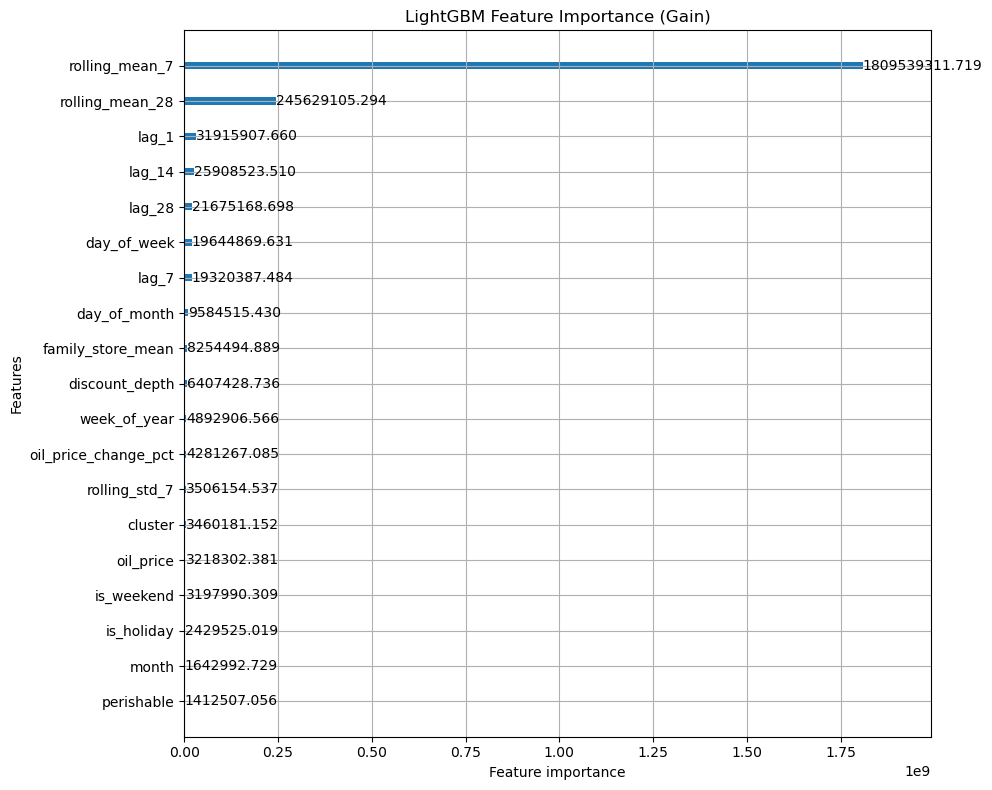

Feature importance saved


In [10]:
# Train Final Model

# Train on ALL data after CV is complete
# WHY: CV was for evaluation. Final model uses maximum data.
# More data = better generalization for the 28-day forecast.

print("Training final model on all data...")
print(f"Training rows: {len(df):,}")

X_all = df[FEATURE_COLS]
y_all = df[TARGET]

final_model = lgb.LGBMRegressor(**params)
final_model.fit(X_all, y_all)

# Save model
joblib.dump(final_model, "../outputs/models/lightgbm_final.pkl")
print("Final model saved to outputs/models/lightgbm_final.pkl")

# Feature importance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
lgb.plot_importance(
    final_model,
    max_num_features=19,
    importance_type="gain",
    ax=ax,
    title="LightGBM Feature Importance (Gain)"
)
plt.tight_layout()
plt.savefig("../outputs/feature_importance.png", dpi=100)
plt.show()
print("Feature importance saved")

In [11]:
# Save OOF Predictions and Experiment Log


# Combine all OOF predictions
oof_df = pd.concat(oof_predictions, ignore_index=True)
oof_df.to_parquet(
    "../outputs/oof_predictions.parquet", index=False
)
print(f"OOF predictions saved: {oof_df.shape}")

# Save experiment log
experiment = {
    "model_name":    "lightgbm_global",
    "training_date": datetime.now().isoformat(),
    "params":        {k: str(v) for k, v in params.items()},
    "cv_folds":      5,
    "mae_mean":      round(float(cv_mae),   4),
    "smape_mean":    round(float(cv_smape), 4),
    "bias_mean":     round(float(cv_bias),  4),
    "baseline_smape": 49.99,
    "improvement":   round(float(49.99 - cv_smape), 4),
    "best_model_flag": True,
    "fold_results":  fold_results
}

with open("../outputs/experiments.json", "w") as f:
    json.dump(experiment, f, indent=2)

print("Experiment log saved to outputs/experiments.json")
print()
print("=" * 50)
print("FINAL SUMMARY")
print("=" * 50)
print(f"Baseline SMAPE:    49.99%")
print(f"LightGBM CV SMAPE: {cv_smape:.2f}%")
print(f"Improvement:       {49.99 - cv_smape:.2f}%")
print(f"CV Bias:           {cv_bias:.4f}")
print(f"Model saved:       outputs/models/lightgbm_final.pkl")
print("=" * 50)

OOF predictions saved: (24944111, 7)
Experiment log saved to outputs/experiments.json

FINAL SUMMARY
Baseline SMAPE:    49.99%
LightGBM CV SMAPE: 47.00%
Improvement:       2.99%
CV Bias:           -0.1111
Model saved:       outputs/models/lightgbm_final.pkl


In [12]:
# Improved parameters based on CV results
# WHY each change:
# - More trees: 1000 instead of 500 (model was stopping too early)
# - Lower learning rate: 0.03 (more careful learning)
# - min_child_samples: prevents overfitting on rare items
# - More leaves: captures more complex patterns

params_v2 = {
    "objective":              "tweedie",
    "tweedie_variance_power": 1.1,
    "metric":                 "mae",
    "learning_rate":          0.03,
    "num_leaves":             128,
    "n_estimators":           1000,
    "min_child_samples":      50,
    "feature_fraction":       0.8,
    "bagging_fraction":       0.8,
    "bagging_freq":           1,
    "random_state":           42,
    "verbose":               -1,
    "n_jobs":                -1
}

print("Improved parameters defined")
print("Key changes from v1:")
print("  n_estimators:    500  → 1000")
print("  learning_rate:   0.05 → 0.03")
print("  num_leaves:       64  → 128")
print("  min_child_samples: added = 50")
print("  feature/bagging fraction: added = 0.8")

Improved parameters defined
Key changes from v1:
  n_estimators:    500  → 1000
  learning_rate:   0.05 → 0.03
  num_leaves:       64  → 128
  min_child_samples: added = 50
  feature/bagging fraction: added = 0.8


In [14]:
fold_results_v2 = []
oof_predictions_v2 = []

print("Running CV with improved parameters...")
print("=" * 50)

for fold in range(1, 6):
    train_dates = unique_dates[:fold * fold_size]
    val_dates   = unique_dates[fold * fold_size:(fold+1) * fold_size]

    if len(val_dates) == 0:
        continue

    train_mask = df["date"].isin(train_dates)
    val_mask   = df["date"].isin(val_dates)

    X_train = df.loc[train_mask, FEATURE_COLS]
    y_train = df.loc[train_mask, TARGET]
    X_val   = df.loc[val_mask,   FEATURE_COLS]
    y_val   = df.loc[val_mask,   TARGET]

    model_v2 = lgb.LGBMRegressor(**params_v2)
    model_v2.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(200)
        ]
    )

    preds = np.clip(model_v2.predict(X_val), 0, None)

    fold_smape = smape(y_val.values, preds)
    fold_mae   = float(mean_absolute_error(y_val, preds))
    fold_bias  = bias(y_val.values, preds)

    fold_results_v2.append({
        "fold":  fold,
        "smape": round(fold_smape, 4),
        "mae":   round(fold_mae,   4),
        "bias":  round(fold_bias,  4)
    })

    oof_df = df.loc[val_mask, ["date","store_nbr","item_nbr",
                                "unit_sales","family"]].copy()
    oof_df["predicted"] = preds
    oof_df["fold"]      = fold
    oof_predictions_v2.append(oof_df)

    print(f"Fold {fold}: SMAPE={fold_smape:.2f}%  "
          f"MAE={fold_mae:.4f}  "
          f"Bias={fold_bias:.4f}")

print("=" * 50)
cv_smape_v2 = np.mean([r["smape"] for r in fold_results_v2])
cv_mae_v2   = np.mean([r["mae"]   for r in fold_results_v2])
cv_bias_v2  = np.mean([r["bias"]  for r in fold_results_v2])

print(f"V2 CV SMAPE: {cv_smape_v2:.2f}% "
      f"± {np.std([r['smape'] for r in fold_results_v2]):.2f}%")
print(f"V2 CV MAE:   {cv_mae_v2:.4f}")
print(f"V2 CV Bias:  {cv_bias_v2:.4f}")
print()
print(f"V1 SMAPE: 47.00%")
print(f"V2 SMAPE: {cv_smape_v2:.2f}%")
print(f"Baseline: 49.99%")

Running CV with improved parameters...
[200]	valid_0's l1: 3.51838
[400]	valid_0's l1: 3.51107
Fold 1: SMAPE=46.72%  MAE=3.5077  Bias=-0.3555
[200]	valid_0's l1: 3.40009
[400]	valid_0's l1: 3.38435
[600]	valid_0's l1: 3.37001
[800]	valid_0's l1: 3.36347
[1000]	valid_0's l1: 3.36278
Fold 2: SMAPE=46.44%  MAE=3.3616  Bias=-0.0335
[200]	valid_0's l1: 3.37804
[400]	valid_0's l1: 3.34766
[600]	valid_0's l1: 3.3395
[800]	valid_0's l1: 3.33473
[1000]	valid_0's l1: 3.33141
Fold 3: SMAPE=46.62%  MAE=3.3313  Bias=-0.0782
[200]	valid_0's l1: 3.1925
[400]	valid_0's l1: 3.16736
[600]	valid_0's l1: 3.16152
[800]	valid_0's l1: 3.15858
[1000]	valid_0's l1: 3.15663
Fold 4: SMAPE=46.87%  MAE=3.1566  Bias=-0.0492
[200]	valid_0's l1: 3.36699
[400]	valid_0's l1: 3.33315
[600]	valid_0's l1: 3.32119
[800]	valid_0's l1: 3.31271
[1000]	valid_0's l1: 3.30804
Fold 5: SMAPE=47.88%  MAE=3.3080  Bias=-0.0449
V2 CV SMAPE: 46.91% ± 0.51%
V2 CV MAE:   3.3330
V2 CV Bias:  -0.1123

V1 SMAPE: 47.00%
V2 SMAPE: 46.91%
Base

In [ ]:
# Use whichever version performed better
best_smape = min(47.00, cv_smape_v2)
best_params = params if 47.00 <= cv_smape_v2 else params_v2
best_version = "v1" if 47.00 <= cv_smape_v2 else "v2"

print(f"Best model: {best_version} with {best_smape:.2f}% SMAPE")

# Retrain best on all data
print("Retraining best model on full dataset...")
final_model_best = lgb.LGBMRegressor(**best_params)
final_model_best.fit(df[FEATURE_COLS], df[TARGET])

joblib.dump(
    final_model_best,
    "../outputs/models/lightgbm_final.pkl"
)
print("Best model saved")

# Update experiment log
oof_final = pd.concat(
    oof_predictions_v2 if best_version == "v2"
    else oof_predictions,
    ignore_index=True
)
oof_final.to_parquet(
    "../outputs/oof_predictions.parquet", index=False
)

experiment_v2 = {
    "model_name":      f"lightgbm_global_{best_version}",
    "training_date":   datetime.now().isoformat(),
    "params":          {k: str(v) for k, v in best_params.items()},
    "cv_folds":        len(fold_results_v2),
    "smape_mean":      round(float(best_smape),  4),
    "mae_mean":        round(float(cv_mae_v2),   4),
    "bias_mean":       round(float(cv_bias_v2),  4),
    "baseline_smape":  49.99,
    "improvement":     round(float(49.99 - best_smape), 4),
    "best_model_flag": True,
    "fold_results":    fold_results_v2
}

with open("../outputs/experiments.json", "w") as f:
    json.dump(experiment_v2, f, indent=2)

print("Experiment log updated")
print(f"\nFinal improvement over baseline: "
      f"{49.99 - best_smape:.2f}% SMAPE reduction")

Best model: v2 with 46.91% SMAPE
Retraining best model on full dataset...
